# Atividade 3 -- Análise de Regressão:
 
 Enunciado: "**Pule a 1ª e a 2ª etapa; Faça teste Global e teste T's**

E a partir dos teste t's de construções, faça teste F parcial. Use type III de teste t em R.

Item adicional: Inclue Intervalo de Confiança e testes para os elementos do $\underset{\sim}{\beta}= \mathbf{\beta}$
"

### Etapa 3:

1. Ajustar o modelo
2. Fazer Diagnóstico
3. Se passar pelo crivo/análise de resíduo --> prossiga
4. Inclua a parte de detecção de outliers e pontos influentes. Opções: $H_{ii}$; DF-Betas; DF-Fits; D-Cook
5. Após análise de resíduo faça testes: F-Global; t; F-Parcial
### Etapa 4:
**Validação** 

Procurar a resposta da seguinte questão: **O modelo é útil para uma nova Base de dados??**

O que pode ser feito é antes de ajustar o modelo, separar um conjunto pequeno para validar depois.

---


### Contexto

Nesta atividade, será realizada uma análise de um conjunto de dados dito na sala de aula, usando um modelo(dado) de regressão linear. A partir desses dados, serão conduzidos: Diagnóstico/Análise de resíduos; Detecção de outliers e pontos influentes; Testes estatísticas; e validação do modelo.

O conjunto de dados é composto por 3 covariáveis e 1 variável resposta:

* X1: Anos de Experiência profissional
* X2: Anos de Escolaridade
* X3: Variável dummy, é 1 ou 0. 1 significa **Privado**, 0 significa **Público**
* Y: log(Salário).

O modelo dado é:

$Y = log(salário) = {\beta}_0 + {\beta}_1*x_1 + {\beta}_2*x_2 + {\beta}_3*x_1x_2 + {\beta}_4*x_3 + {\epsilon}$

---

# Análise

### 1.Preparar os dados

In [ ]:
X1 <- c(2, 5, 8, 3, 10, 1, 6, 4, 9, 7, 2, 11)
X2 <- c(8, 12, 16, 11, 16, 8, 12, 11, 16, 12, 9, 18)
X3 <- c(1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1)
Y <- c(8.393, 9.169, 10.444, 8.539, 11.095, 7.845, 9.450, 8.489, 10.847, 9.747, 8.025, 11.904)

#data frame
dados <- data.frame(X1, X2, X3, Y)

#a interação X1*X2
dados$X1X2 <- dados$X1 * dados$X2

#o modelo conforme enunciado
modelo <- lm(Y ~ X1 + X2 + X1X2 + X3, data = dados)
summary(modelo)


Call:
lm(formula = Y ~ X1 + X2 + X1X2 + X3, data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.18619 -0.05445 -0.01511  0.06320  0.15178 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 7.468723   0.580021  12.877 3.96e-06 ***
X1          0.034680   0.080972   0.428  0.68131    
X2          0.029003   0.073068   0.397  0.70324    
X1X2        0.017016   0.004235   4.018  0.00507 ** 
X3          0.203664   0.113808   1.790  0.11666    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.1287 on 7 degrees of freedom
Multiple R-squared:  0.994,	Adjusted R-squared:  0.9906 
F-statistic: 289.3 on 4 and 7 DF,  p-value: 7.549e-08


### 2. Diagnóstico
Verificando se as suposições são razoáveis:
- Linearidade
- Normalidade dos resíduos
- Homocedasticidade
- Independência
- Ausência/Presença de outliers influentes

#### 2.1 Gráficos

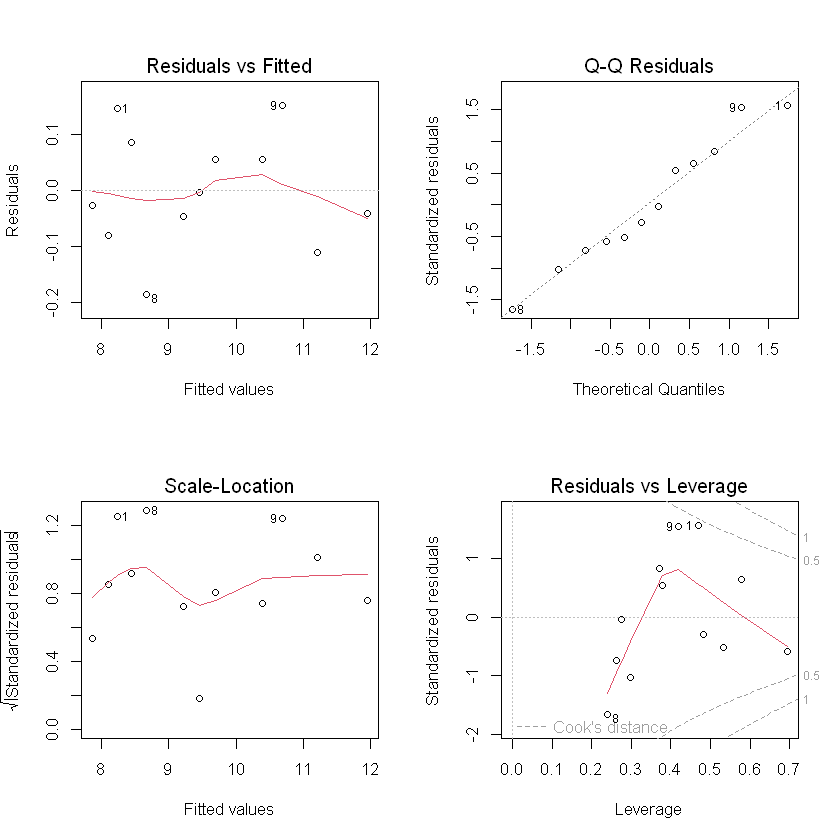

In [2]:
# Gráficos padrão do R para diagnóstico
par(mfrow = c(2,2))
plot(modelo)
par(mfrow = c(1,1))

O que os gráficos indicam:

- Residuals vs Fitted – verifica linearidade e homocedasticidade. Pontos devem cair aleatoriamente em torno de zero, sem padrão curvilíneo ou funil.

- Q‑Q plot – normalidade dos resíduos. Pontos devem ficar próximos à reta diagonal.

- Scale‑Location – raiz quadrada dos resíduos padronizados vs valores ajustados. Ajuda a detectar heterocedasticidade (tendência inclinada ou funil).

- Residuals vs Leverage – identifica observações com alta alavancagem e potencial influência. Distância de Cook aparece como contornos.

Como a amostra é pequena (n=12), é comum alguma flutuação, mas com os gráficos, pode-se dizer que os pressupostos são razoavelmente atendidos.

#### 2.2 Testes para Normalidade e Homocedasticidade

In [4]:
# Teste de Shapiro-Wilk para normalidade dos resíduos
shapiro.test(residuals(modelo))

# Teste de Breusch-Pagan para homocedasticidade
library(lmtest)
bptest(modelo)   # H0: homocedasticidade


	Shapiro-Wilk normality test

data:  residuals(modelo)
W = 0.9698, p-value = 0.9087


Carregando pacotes exigidos: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric





	studentized Breusch-Pagan test

data:  modelo
BP = 1.8573, df = 4, p-value = 0.762


Interpretação de resultados:

Shapiro-Wilk: valor-p = 0.9087 → não rejeita normalidade.
Breusch‑Pagan: valor-p = 0.762 → evidência de homocedasticidade.

#### 2.3 Detecção de Outliers e pontos influentes

Medidas usadas:

Alavancagem (Hii) – valores altos indicam observações com potencial para puxar a regressão. Limiar comum: 2*(p+1)/n, onde p = número de preditores (aqui p=4).

DFBETAS – mudança no coeficiente quando a observação é removida. Limite: 2/√n.

DFFITS – mudança nos valores preditos. Limite: 2*√((p+1)/n).

Distância de Cook – influência global. Limite: >1 indica ponto muito influente (também usado 4/n como referência).

In [6]:
#medidas de alavancagem e influência
hat_values <- hatvalues(modelo)
cooks_d <- cooks.distance(modelo)
dfbetas <- dfbetas(modelo)
dffits <- dffits(modelo)

#limiares
n <- nrow(dados)
p <- length(coef(modelo)) - 1   # número de preditores (exclui intercepto)
lim_hat <- 2 * (p+1) / n
lim_dfbeta <- 2 / sqrt(n)
lim_dffit <- 2 * sqrt((p+1)/n)

#um dataframe de medidas para identificar observações que ultrapassam os limiares
influentes <- data.frame(
  obs = 1:n,
  hat = hat_values,
  cook = cooks_d,
  dffit = dffits,
  dfbeta_max = apply(abs(dfbetas), 1, max) 
)

print(influentes)
cat("\nLimiar Hii =", lim_hat, "\nLimiar |DFFITS| =", lim_dffit, "\nLimiar |DFBETAS| =", lim_dfbeta, "\n")

   obs       hat         cook       dffit dfbeta_max
1    1 0.4693599 4.346538e-01  1.69418827 0.72923605
2    2 0.5337557 6.217166e-02 -0.52650078 0.41831343
3    3 0.3783860 3.669644e-02  0.40539782 0.20652491
4    4 0.3722413 8.368641e-02  0.63155746 0.44373520
5    5 0.2983020 8.983406e-02 -0.67338459 0.23557605
6    6 0.4826143 1.535414e-02 -0.25804328 0.16318761
7    7 0.2745160 8.485247e-05 -0.01907123 0.01133163
8    8 0.2388491 1.725438e-01 -1.10351523 0.61430298
9    9 0.4178732 3.429358e-01  1.49366721 1.10663077
10  10 0.5775299 1.158410e-01  0.72694361 0.59963957
11  11 0.2627931 3.773958e-02 -0.41829743 0.20139357
12  12 0.6937795 1.510843e-01 -0.82455384 0.49869678

Limiar Hii = 0.8333333 
Limiar |DFFITS| = 1.290994 
Limiar |DFBETAS| = 0.5773503 


Interpretação:

Observações com hat > lim_hat são pontos de alavancagem; com cook > 1 (ou >4/n) são muito influentes; |dffit| > lim_dffit e |dfbeta| > lim_dfbeta indicam influência sobre predições ou coeficientes.

### 3. Testes estatísticos
#### 3.1 Teste F Global:

Verifica se pelo menos um preditor é útil ($H_0: {\beta}_1={\beta}_2={\beta}_3={\beta}4=0$).

In [7]:
summary(modelo)$fstatistic
# Ou usando anova:
anova(modelo)   # tabela de soma de quadrados sequencial
# O teste F global já aparece no final do summary(modelo), mas podemos extrair:
f_global <- summary(modelo)$fstatistic
p_global <- pf(f_global[1], f_global[2], f_global[3], lower.tail = FALSE)
cat("F global =", f_global[1], ", gl1 =", f_global[2], ", gl2 =", f_global[3],
    ", p-valor =", p_global, "\n")

value    numdf    dendf 
289.3089   4.0000   7.0000

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
X1,1,18.78851770,18.78851770,1134.123858,5.274110e-09
X2,1,0.04294874,0.04294874,2.592498,1.514062e-01
X1X2,1,0.28687708,0.28687708,17.316648,4.234732e-03
X3,1,0.05305355,0.05305355,3.202451,1.166563e-01
Residuals,7,0.11596584,0.01656655,NA,NA


F global = 289.3089 , gl1 = 4 , gl2 = 7 , p-valor = 7.548785e-08 


Interpretação: p‑valor = 7.5e-08, é baixissimo → rejeitamos $H_0$; o modelo tem poder explicativo.

#### 3.2 Testes t individuais (Type III)

In [8]:
library(car)
Anova(modelo, type = "III")

Carregando pacotes exigidos: carData



,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),2.746860478,1,165.8076519,3.956081e-06
X1,0.003038877,1,0.1834345,6.813079e-01
X2,0.002610254,1,0.1575617,7.032353e-01
X1X2,0.267504571,1,16.1472726,5.070111e-03
X3,0.053053553,1,3.2024506,1.166563e-01
Residuals,0.115965838,7,NA,NA


Cada linha fornece a estatística F parcial e p‑valor para o termo. 

In [9]:
confint(modelo, level = 0.95)

,2.5 %,97.5 %
(Intercept),6.097190431,8.84025621
X1,-0.156788009,0.22614714
X2,-0.143773818,0.20178075
X1X2,0.007002938,0.02702941
X3,-0.065449320,0.47277734


Estes são intervalos de confiança (bicaudais) para cada coeficiente, baseados na distribuição t.

---

#### 3.3 Teste F parcial (a partir dos testes t)

1) Testar a interação X1 e X2 ($H_0: {\beta}_3 = 0$)

In [10]:
# Modelo reduzido (sem interação)
modelo_red1 <- lm(Y ~ X1 + X2 + X3, data = dados)
# Teste F parcial entre completo e reduzido
anova(modelo_red1, modelo)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,8,0.3834704,NA,NA,NA,NA
2,7,0.1159658,1,0.2675046,16.14727,0.005070111


Valor-p = 0.005, é pequeno, a interação entre X1 e X2 é significativa, rejeita $H_0$.

---

2) Testar a dummy X3 ($H_0: {\beta}_4 = 0$)

In [11]:
modelo_red2 <- lm(Y ~ X1 + X2 + X1X2, data = dados)
anova(modelo_red2, modelo)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,8,0.1690194,NA,NA,NA,NA
2,7,0.1159658,1,0.05305355,3.202451,0.1166563


Valor-p = 0.11, não é pequeno, a variável X3 não é significativa, não rejeita $H_0$.

---

3) Testar simultaneamente dois coeficientes (ex.: $X_2$ e $X_1X_2$) ($H_0: {\beta}_2 = {\beta}_3 = 0$)

In [12]:
modelo_red3 <- lm(Y ~ X1 + X3, data = dados)   # remove X2 e interação
anova(modelo_red3, modelo)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,9,0.4971231,NA,NA,NA,NA
2,7,0.1159658,2,0.3811573,11.50382,0.006131


Valor-p = 0.006,  é pequeno, $X2$ e $X_1X_2$ são significativas, rejeita $H_0$.

---

Interpretação: Cada teste F parcial compara a redução da soma de quadrados dos resíduos com a complexidade adicional do modelo completo. Um p‑valor baixo indica que o(s) termo(s) adicionado(s) melhora(m) significativamente o ajuste.

---

### 4. Validação do modelo

#### 4.1 Separar conjunto de treino e teste

Como n=12, vou separar 10 observações para treino e 2 para teste (escolher aleatoriamente, mas semente fixa). Opcionalmente, pode-se escolher qualquer divisão pequena, pois é válida para demonstração.

In [13]:
set.seed(20260505)   # para repetibilidade
indices_teste <- sample(1:n, size = 2, replace = FALSE)

treino <- dados[-indices_teste, ]
teste <- dados[indices_teste, ]

#### 4.2 Reajustar o modelo nos dados de treino e prever

In [14]:
modelo_treino <- lm(Y ~ X1 + X2 + X1X2 + X3, data = treino)
pred_teste <- predict(modelo_treino, newdata = teste)

#### 4.3 Comparar valores reais e previstos

In [15]:
resultado_validacao <- data.frame(
  observado = teste$Y,
  previsto = pred_teste,
  residuo = teste$Y - pred_teste
)

# Métricas de erro
rmse <- sqrt(mean((teste$Y - pred_teste)^2))
mae <- mean(abs(teste$Y - pred_teste))

cat("Resultados da validação:\n")
print(resultado_validacao)
cat("\nRMSE =", round(rmse, 4), "\nMAE =", round(mae, 4), "\n")

Resultados da validação:
  observado previsto     residuo
8     8.489 8.717003 -0.22800256
4     8.539 8.462886  0.07611442

RMSE = 0.17 
MAE = 0.1521 


Interpretação: Valores pequenos de RMSE/MAE indicam boa capacidade preditiva. Como o conjunto de teste é pequeno, essas métricas são apenas ilustrativas.

Pode-se até dizer que o modelo é útil, mas não melhor não dizer com muita certeza pois a amostra é pequena